In [42]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Assuming files are stored in "saved-fees-updated" directory
data_dir = '../coin-selection-c-master/simulation/results'
files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

# Predefined colors for each strategy
strategy_colors = {
#    'MAX_BILLS': 'blue',
#    'CLOSEST_TO_EXPIRE_MIN_BILLS': 'orange',
#    'CLOSEST_TO_EXPIRE_MAX_BILLS': 'cyan',
#    'MAX_BILLS_TIME_TO_EXPIRE_WEIGHTED': 'blue',
    'RANDOM': 'magenta',
#    'MIN_BILLS': 'blue',
#    'EVEN_FROM_MIN_TO_MAX': 'red',
#    'EVEN_FROM_MAX_TO_MIN': 'pink',
    'WALLET_CORE': 'cyan',
    'GREEDY_MIN_TO_MAX_FIX': 'red',
    'GREEDY_MAX_TO_MIN_FIX': 'orange',
    'CALL_EXTERNAL': 'black'
}

# Initialize an empty list to hold all data
all_data = []

# Process each file
for file_name in files:
    file_path = os.path.join(data_dir, file_name)
    with open(file_path, 'r') as file:
        # Read user type and strategy from the first line
        user_type, strategy = file.readline().strip().split(', ')
        
        # Parse the rest of the data
        for line in file:
            id, time, amount, operation, fee, coin_count, *_ = line.strip().split(', ')  # Updated here to include 'amount'
            all_data.append({
                "UserType": user_type,
                "Strategy": strategy,
                "Id": id,
                "Time": int(time),
                "Amount": int(amount),  
                "Operation": operation,  
                "Fee": int(fee),
                "FileName": file_name,
                "CoinCount": int(coin_count)
            })
        

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(all_data)


# Filter out DEPOSIT_REFRESH_OP right away
#df = df[(df['Operation'] != 'DEPOSIT_REFRESH_OP') & (df['Amount'] > 0)] # removed "& (df['Amount'] < 500000)" here

df['Days'] = df['Time']/3600/24

df.set_index("Days", inplace=True)

user_types = df["UserType"].unique()
strategies = df["Strategy"].unique()

n_user_types = df["UserType"].nunique()
n_strats = df["Strategy"].nunique()

cols = min(n_user_types, 2)
rows = np.ceil(n_user_types / cols).astype(int)

df["SignAmount"] = 0
df["SignAmount"] = df['Amount'].where(df["Operation"] == "WITHDRAW_OP", -df["Amount"]) - df["Fee"]

file_groups = df.groupby('FileName')
df["Balance"] = file_groups['SignAmount'].cumsum()
# Calculate cumulative fees for each file within each strategy
df['CumulativeFee'] = df.groupby(['FileName', 'UserType', 'Strategy'])['Fee'].cumsum()
fees_by_op = df.groupby(["UserType", "Strategy", "Operation"])["Fee"].sum()

#print(file_groups["CoinCount"].shift(1, fill_value=0) - file_groups["CoinCount"])
df["UsedDiskSpace"] = df["CoinCount"]
df["UsedBandwidth"] = 0
df["UsedBandwidth"] = df.groupby(['FileName', 'UserType', 'Strategy'])["CoinCount"].diff().abs().fillna(0).cumsum()

# ???
df["FeeSumWallet"] = df["CoinCount"] + df["CumulativeFee"]
print(df.loc[(df["Strategy"] == 'GREEDY_MAX_TO_MIN_FIX') & (df["UserType"] == 'BALANCED_ARTIST')][["Time","CumulativeFee", "Amount", "Fee", "Balance"]])
print(df.loc[(df["Strategy"] == 'GREEDY_MIN_TO_MAX_FIX') & (df["UserType"] == 'BALANCED_ARTIST')][["Time", "CumulativeFee", "Amount", "Fee", "Balance"]])

Days
0.0         0.0
0.0         7.0
0.0        15.0
1.0        15.0
1.0        19.0
2.0        19.0
2.0        28.0
3.0        28.0
3.0        31.0
4.0        31.0
4.0        40.0
5.0        40.0
5.0        45.0
6.0        45.0
6.0        49.0
8.0        49.0
8.0        53.0
9.0        53.0
9.0        54.0
0.0      4834.0
0.0      4846.0
0.0      4859.0
0.0      4859.0
0.0      4873.0
0.0      4873.0
0.0      4885.0
1.0      4885.0
1.0      4899.0
1.0      4899.0
1.0      4911.0
1.0      4911.0
1.0      4917.0
2.0      4917.0
2.0      4927.0
2.0      4927.0
2.0      4936.0
2.0      4936.0
2.0      4944.0
2.0      4944.0
2.0      4953.0
3.0      4953.0
3.0      4965.0
3.0      4965.0
3.0      4973.0
4.0      4973.0
4.0      4979.0
4.0      4979.0
4.0      4987.0
5.0      4987.0
5.0      5000.0
5.0      5000.0
5.0      5010.0
5.0      5010.0
5.0      5020.0
5.0      5020.0
5.0      5029.0
6.0      5029.0
6.0      5040.0
6.0      5040.0
6.0      5052.0
6.0      5052.0
6.0      5062.0
7.0

In [43]:
# Plotting setup
num_users = df['UserType'].nunique()
ncols = min(3, num_users)
nrows = np.ceil(num_users / ncols).astype(int)
plot_multiple = ncols * nrows > 1

def plot_grid(key):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)
    
    axes = axes.ravel()
    
    for idx, (user_type, ax) in enumerate(zip(sorted(user_types), axes)):
        # Prepare boxplot data; collect lists from each cell in row corresponding to user type
        for strategy in strategies:
            #ax.bar(boxplot_data, tick_labels=pivot_df_new.columns, showfliers=False)  # Optionally add `showfliers=False` to hide outliers
            current_data = df[(df["UserType"] == user_type) & (df["Strategy"] == strategy)]
            current_data.plot(y=key, xlabel="Simulation Time (days)", ylabel="Satoshis", label=strategy,
                              ylim=(df[key].min(), df[key].max()), ax=ax)
            ax.set_title(f"User Type: {user_type}", fontsize=26)
            ax.set_ylabel(key, fontsize=22)
            ax.tick_params(axis='x', rotation=45, labelsize=13)
    
    plt.tight_layout()
    plt.savefig(f"results/{key}", bbox_inches='tight')
    plt.show()
    return fig

    

# Cumulative Fee

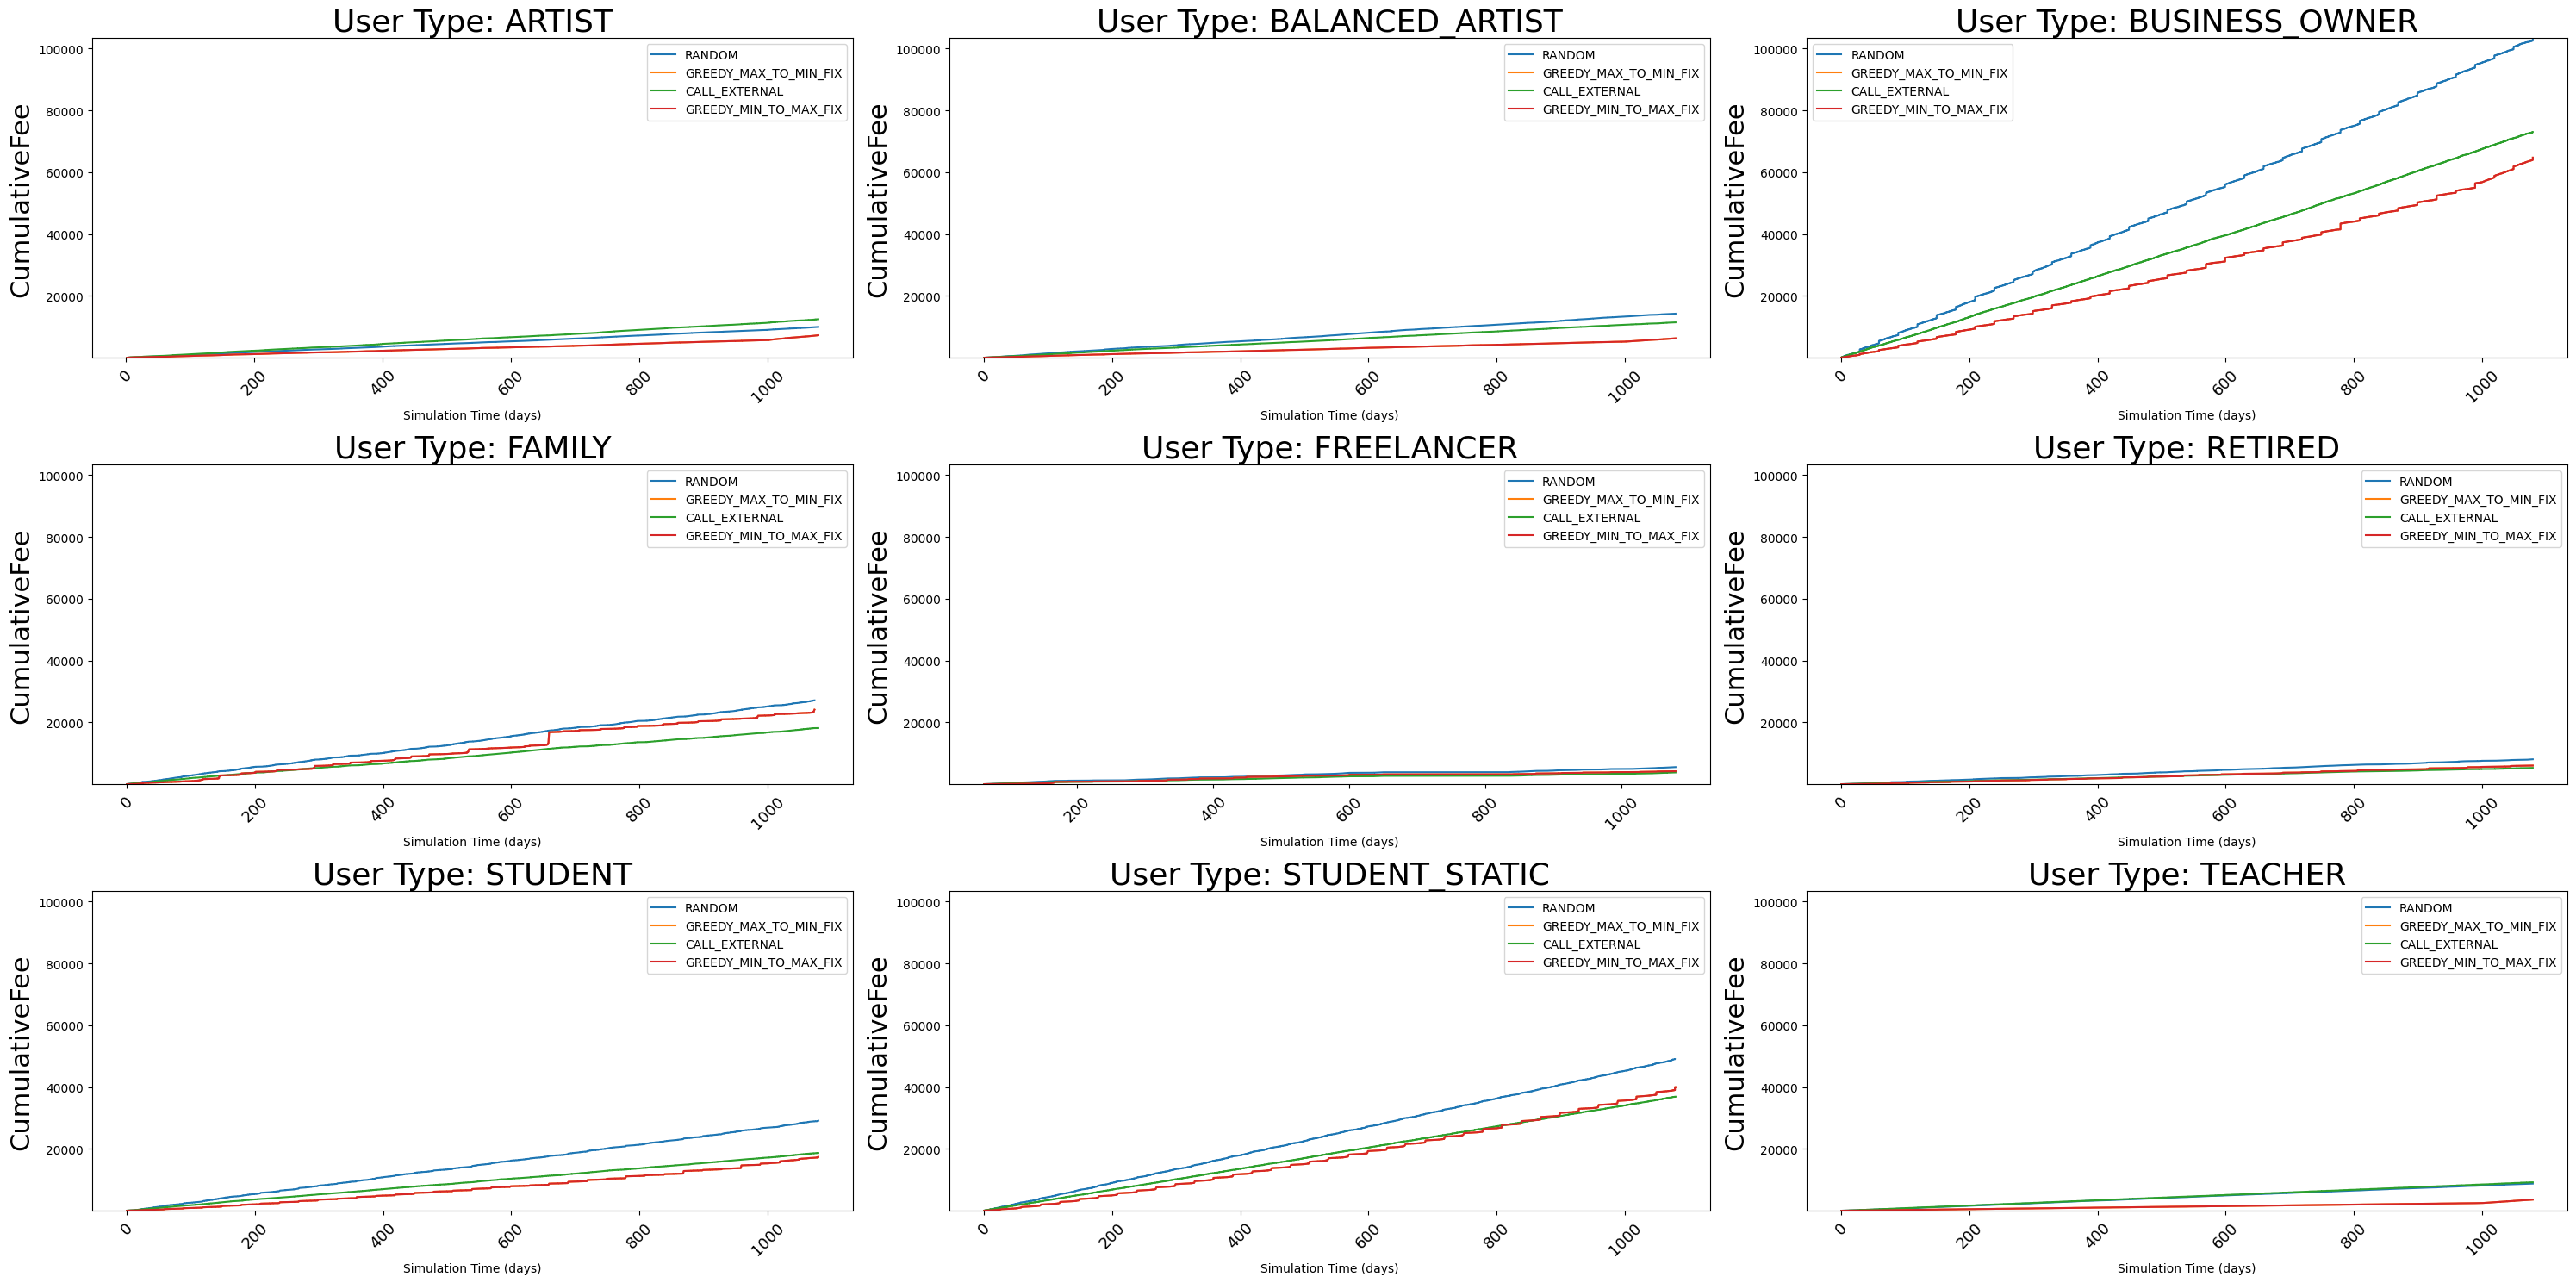

In [14]:
# Create a pivot table for the final cumulative fee for each strategy and user type
final_cumulative_fees = df.drop_duplicates(['FileName', 'UserType', 'Strategy'], keep='last')
# Pivot table adjustment for easier access in the new plot setup
pivot_df_new = final_cumulative_fees.pivot_table(index='UserType', columns='Strategy', values='CumulativeFee', aggfunc=list)

fig = plot_grid("CumulativeFee")
fig.savefig("results/fee_cum_unit", bbox_inches='tight', dpi=300)

# Composition

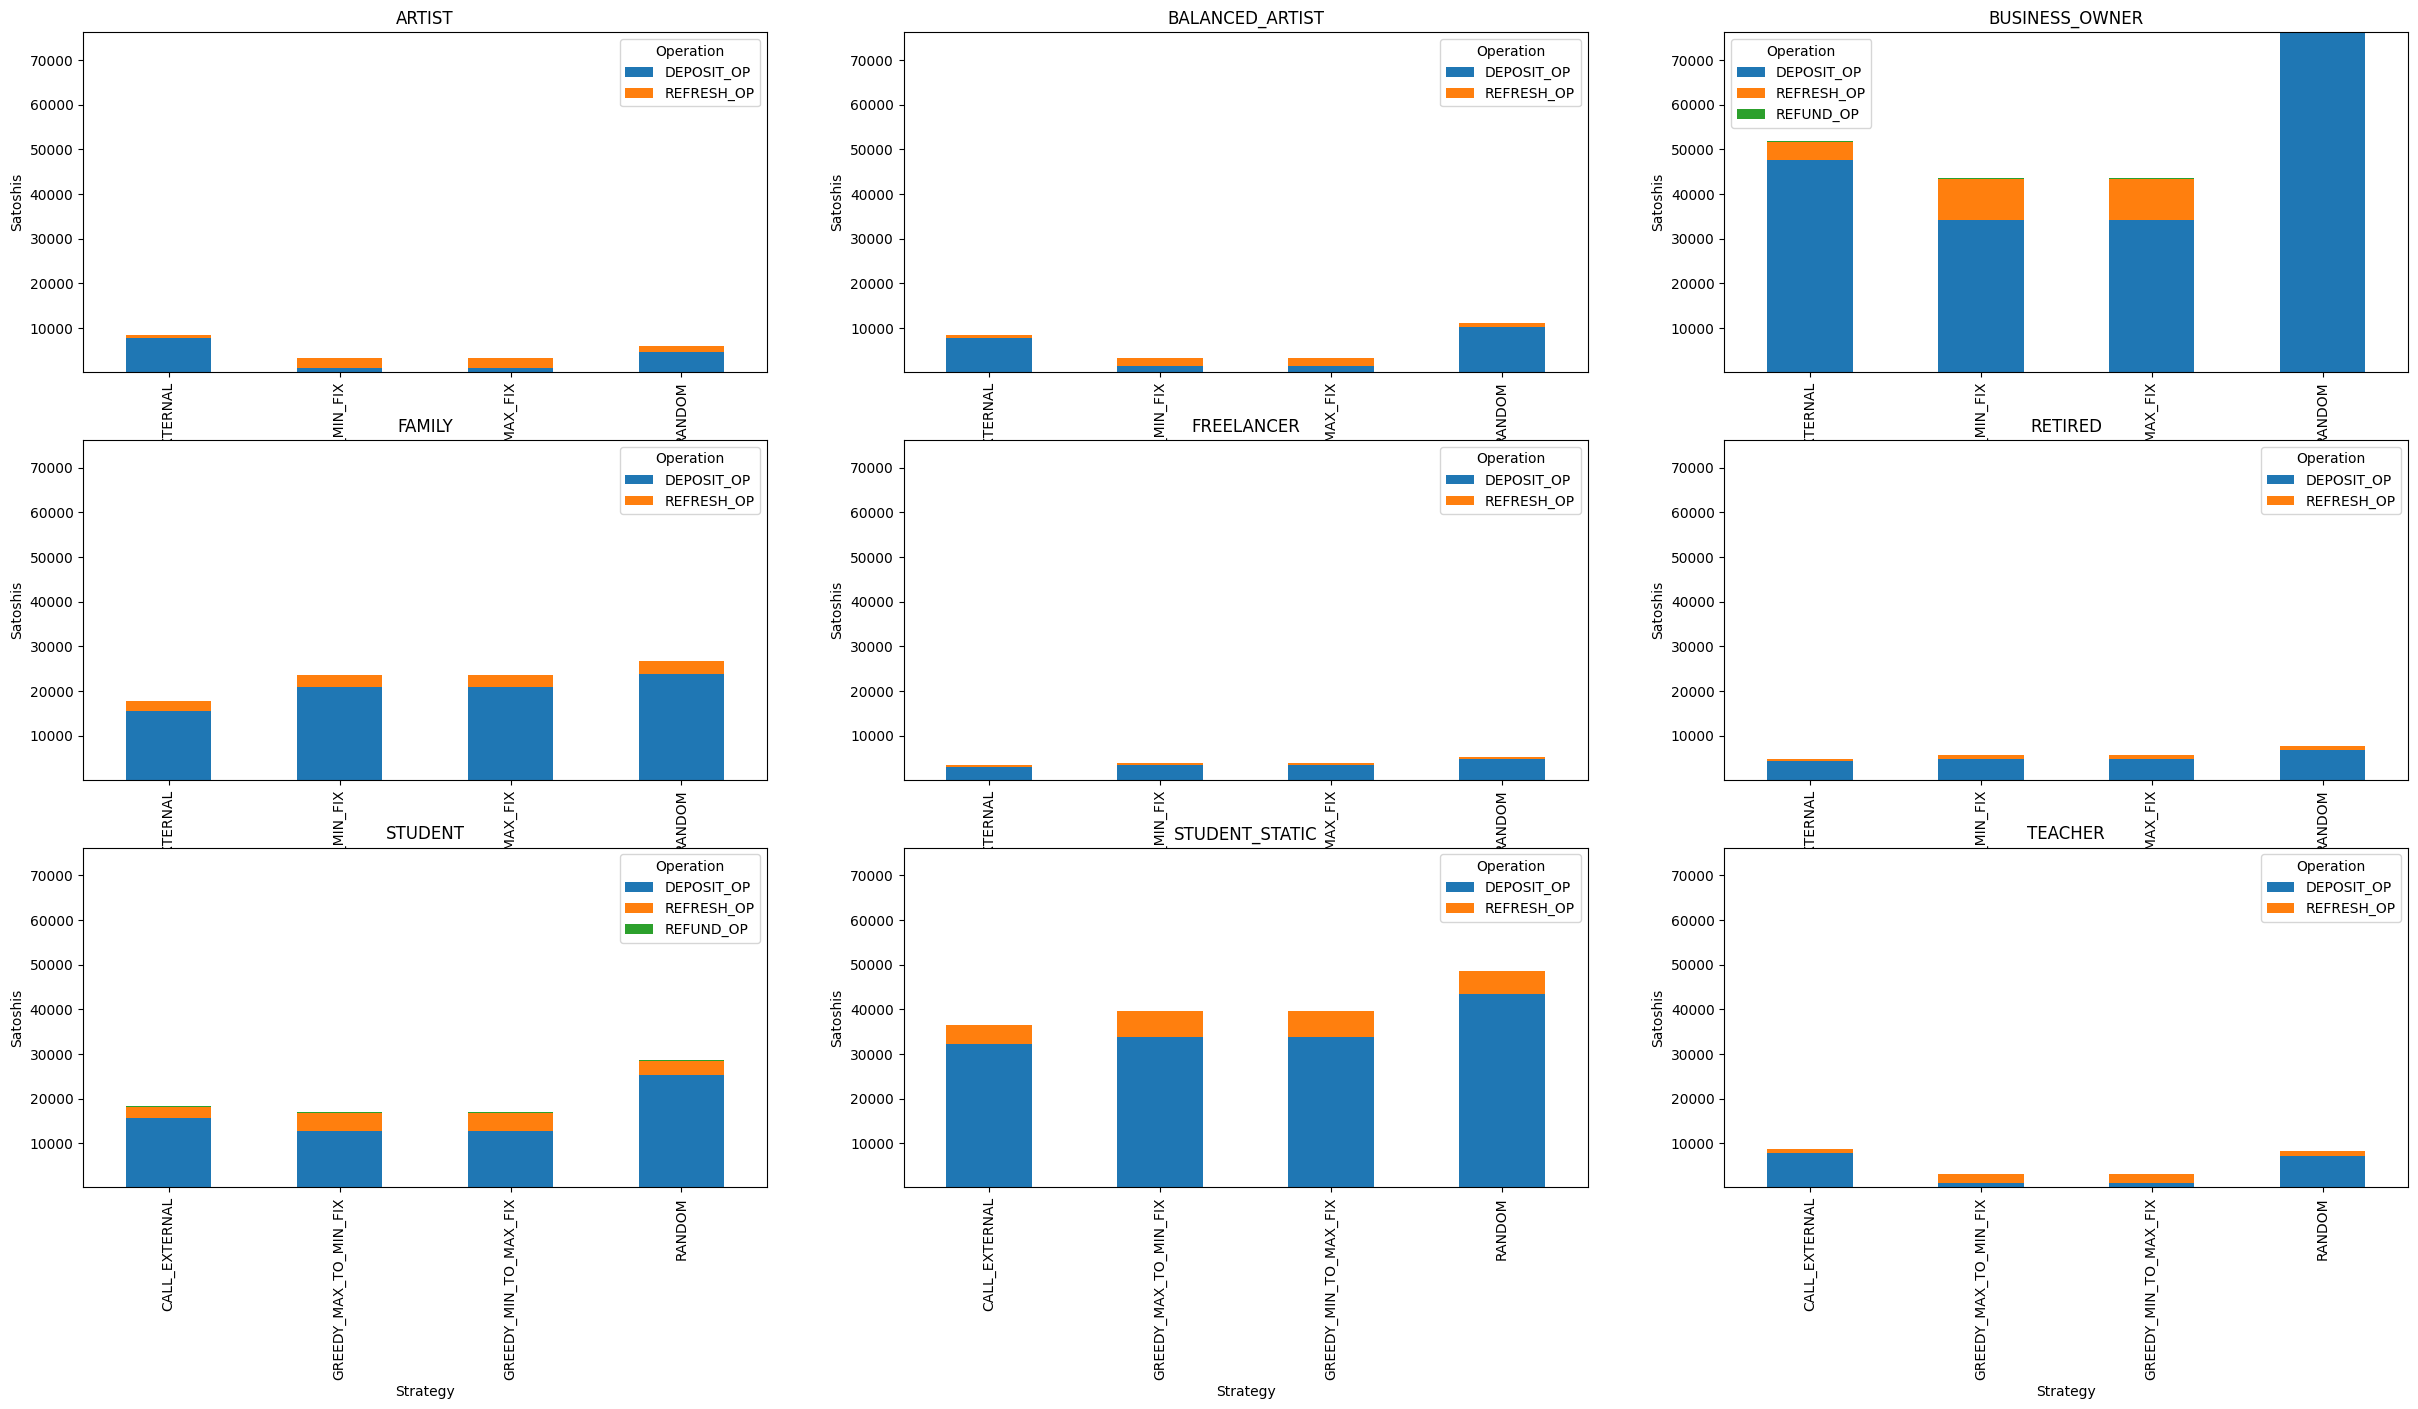

In [28]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)
axes = axes.flatten()
fees_by_op = df.groupby(["UserType", "Strategy", "Operation"])["Fee"].sum().unstack(fill_value=0)
ops = df["Operation"].unique()
sums = df.groupby(['Strategy', 'Operation', 'UserType'])['Fee'].sum()
#print(sums.max())
minmax = sums.min(), sums.max()

for idx, (user_type, ax) in enumerate(zip(sorted(user_types), axes)):
    # Prepare boxplot data; collect lists from each cell in row corresponding to user type

    current_data = df[(df["UserType"] == user_type) & (df["Operation"] != "WITHDRAW_OP")]
    plot_data = current_data.sort_values(["Strategy", "Operation"]).groupby(["Strategy", "Operation"])["Fee"].sum()

    fig = plot_data.unstack().plot(kind="bar", title=user_type, ylim=minmax, stacked=True, ylabel="Satoshis", ax=ax).get_figure()

fig.savefig("results/fee_comp_unit", bbox_inches='tight', dpi=300)

# Resources

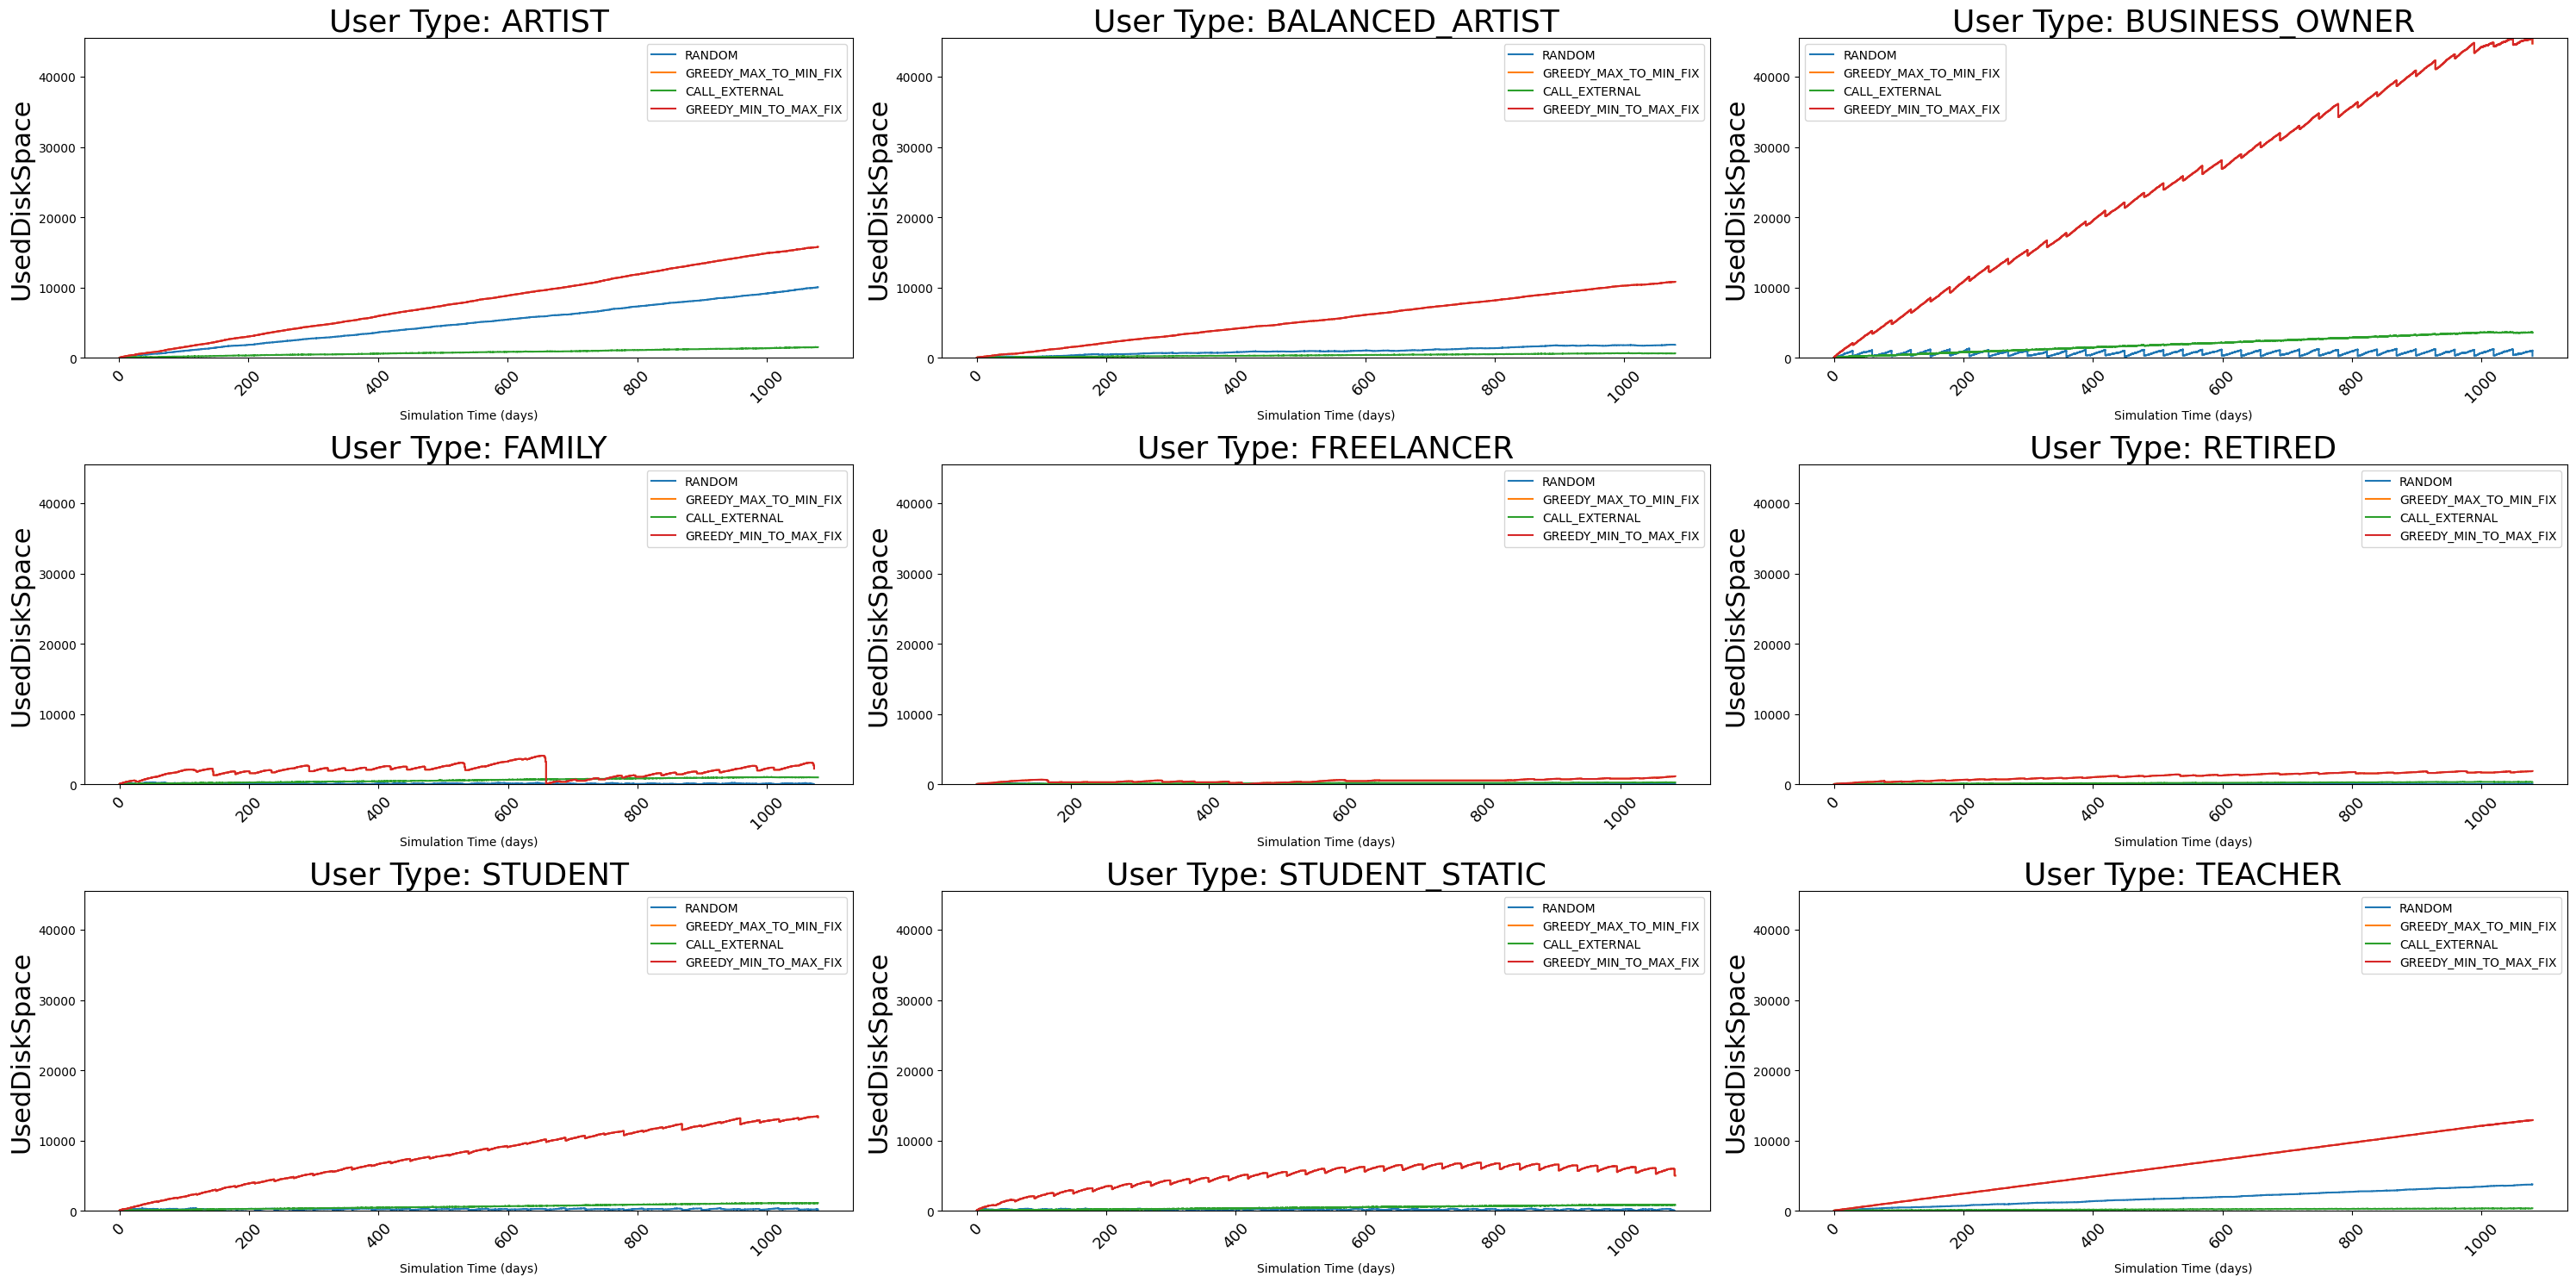

In [44]:
fig = plot_grid("UsedDiskSpace")

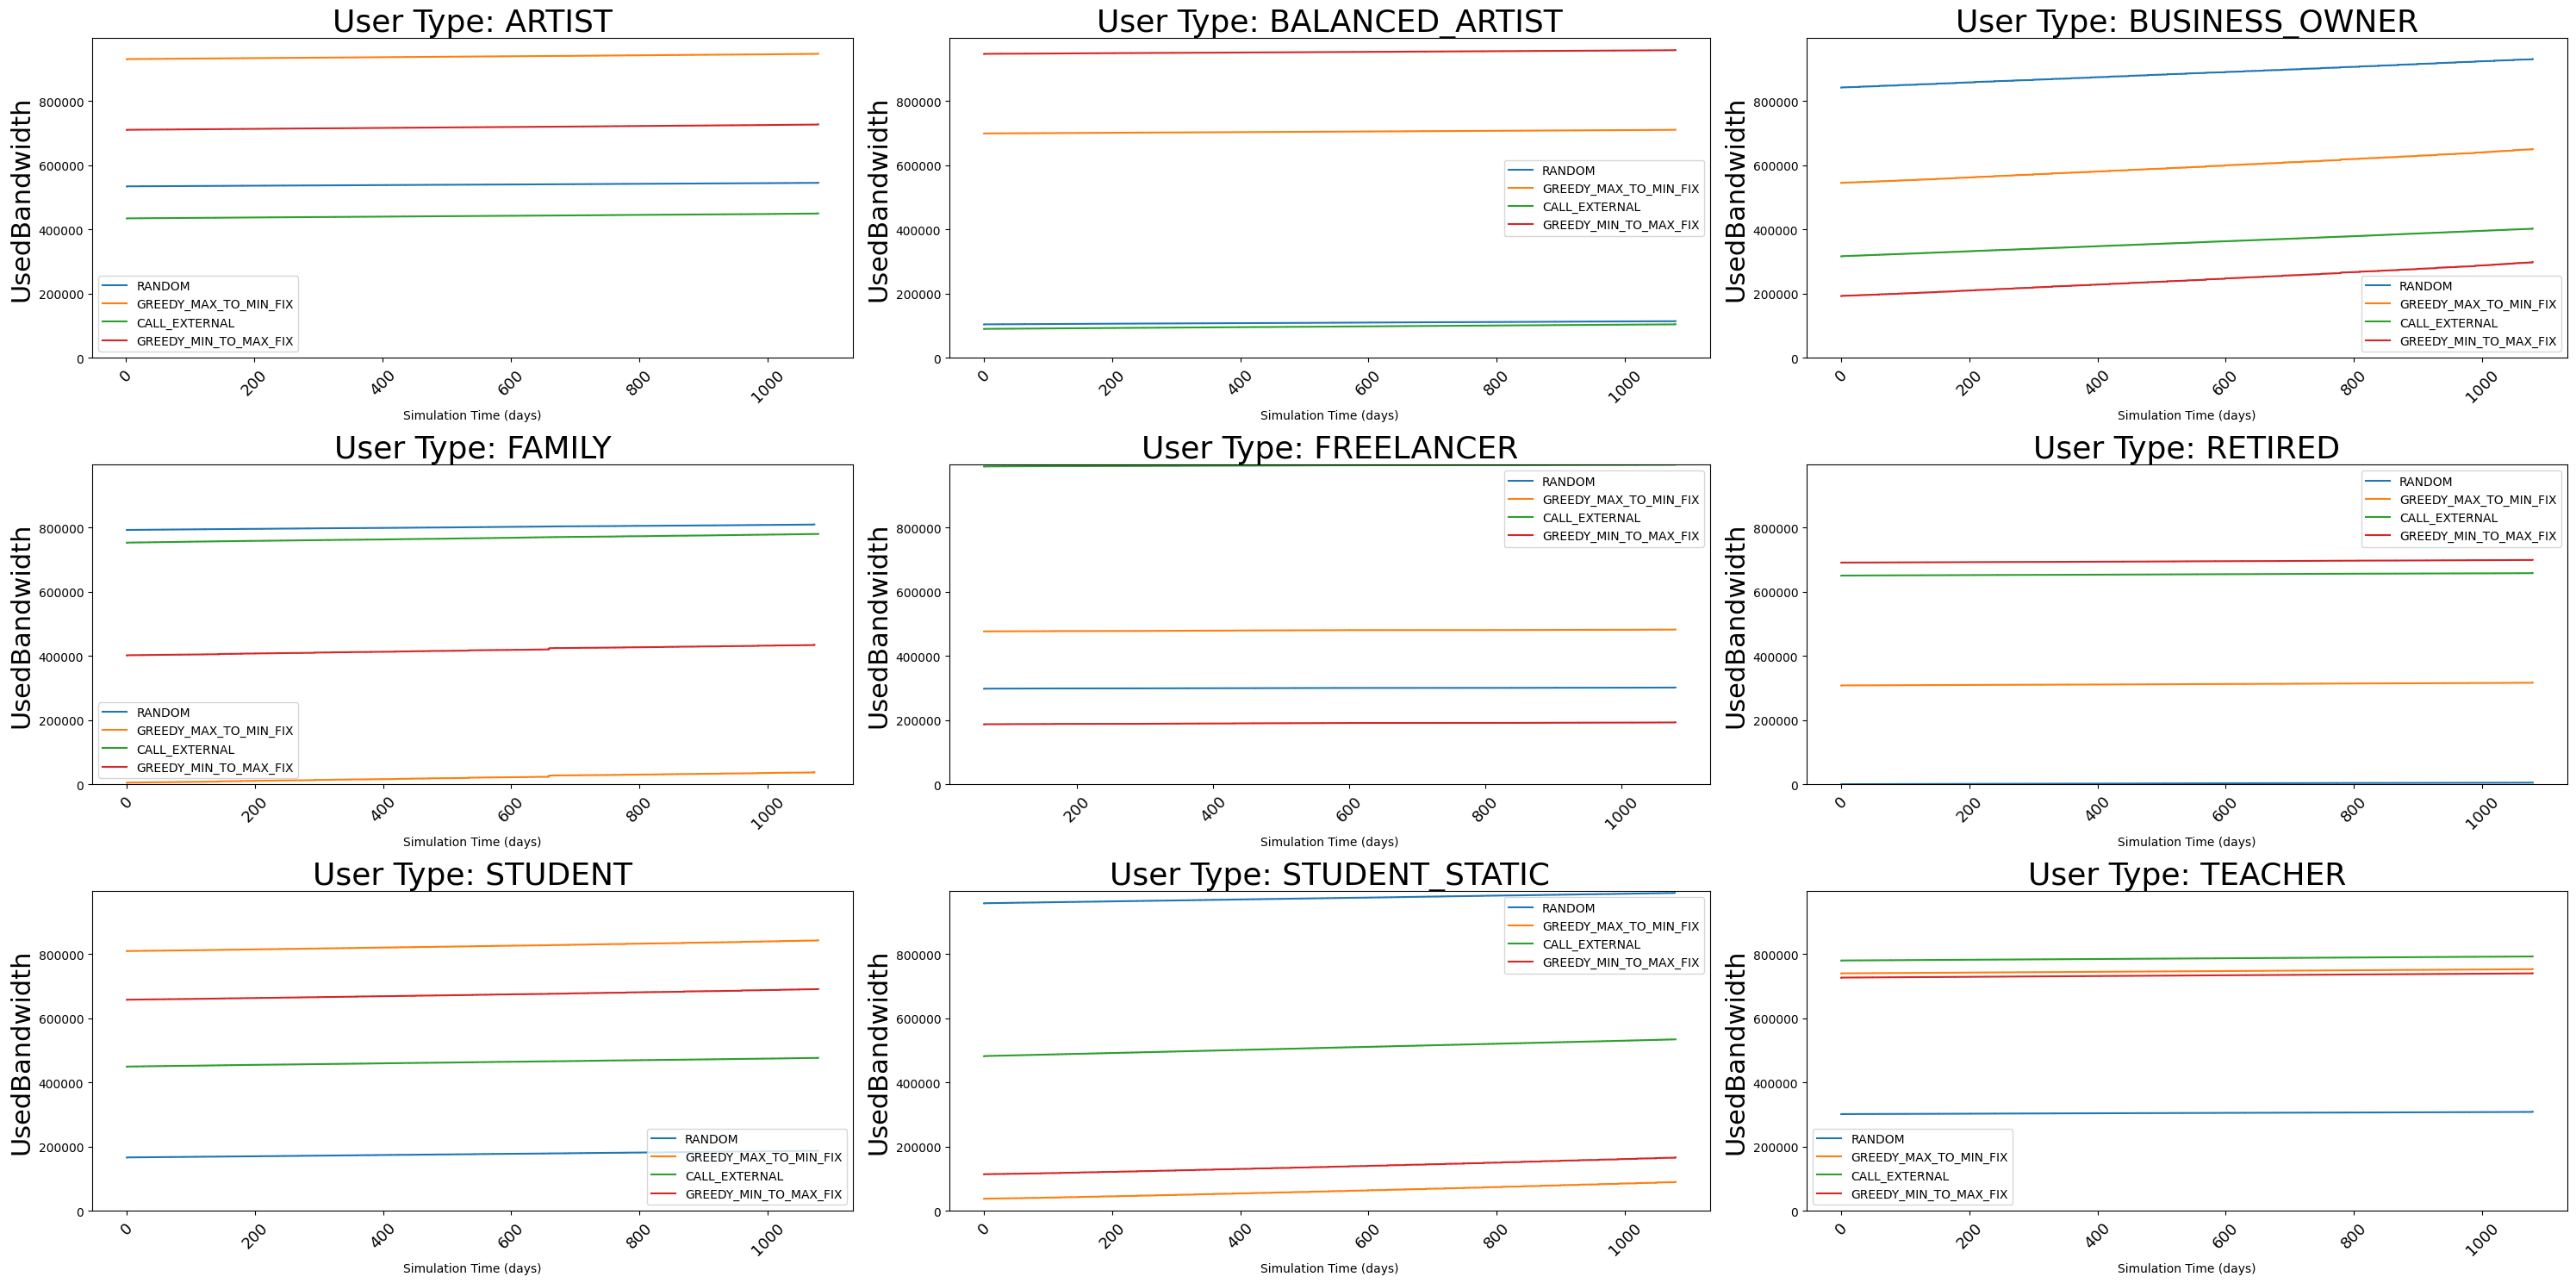

In [35]:
fig = plot_grid("UsedBandwidth")